In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import mplhep as hep
from matplotlib.patches import Rectangle
from pathlib import Path
from typing import List, Union
from scipy.linalg import solve_triangular, qr
import json
plt.style.use(hep.style.CMS)

In [3]:
df_njcat0 = pd.read_csv(
    "/t3home/niharrin/devel/work/devel/RCR_Matrix/bootstrap/bootstrap_sideband_counts_nj_cat0.txt",
    comment="#",          # ignore lines starting with #
    sep=r"\s+",           # split on whitespace
    header=None
)

# set column names manually
df_njcat0.columns = ["replica_idx", "bin0", "bin1", "bin2", "bin3"]

print(df_njcat0)

      replica_idx   bin0   bin1  bin2  bin3
0               0  32031  15159  5442  1973
1               1  31846  15092  5554  1977
2               2  32063  15256  5648  2018
3               3  31776  15253  5486  2050
4               4  31905  15206  5392  2085
...           ...    ...    ...   ...   ...
4995         4995  31864  14804  5541  2065
4996         4996  32201  14956  5650  2049
4997         4997  32360  15171  5479  2066
4998         4998  31757  15210  5523  2091
4999         4999  31875  15142  5612  1976

[5000 rows x 5 columns]


In [4]:
df_pthcat0 = pd.read_csv(
    "/t3home/niharrin/devel/work/devel/RCR_Matrix/bootstrap/bootstrap_sideband_counts_pth_cat0.txt",
    comment="#",          # ignore lines starting with #
    sep=r"\s+",           # split on whitespace
    header=None
)

# set column names manually
df_pthcat0.columns = ["replica_idx", "bin0", "bin1", "bin2", "bin3", "bin4", "bin5", "bin6", "bin7"]

print(df_pthcat0)

      replica_idx   bin0   bin1  bin2   bin3  bin4  bin5  bin6  bin7
0               0  15536  15191  8927   9950  3290  1400   278    33
1               1  15582  14775  9119   9946  3269  1468   268    42
2               2  15731  14928  9078  10047  3358  1526   277    40
3               3  15577  14710  9227   9941  3303  1465   284    58
4               4  15604  14818  9003  10008  3370  1457   277    51
...           ...    ...    ...   ...    ...   ...   ...   ...   ...
4995         4995  15619  14763  9050   9815  3215  1461   314    37
4996         4996  15901  14780  8998  10022  3361  1456   289    49
4997         4997  15849  15137  8945  10088  3280  1471   266    40
4998         4998  15418  14837  9097  10079  3353  1456   294    47
4999         4999  15550  14904  9082  10046  3222  1482   288    31

[5000 rows x 9 columns]


In [5]:
df_ptj0cat0 = pd.read_csv(
    "/t3home/niharrin/devel/work/devel/RCR_Matrix/bootstrap/bootstrap_sideband_counts_ptj0_cat0.txt",
    comment="#",          # ignore lines starting with #
    sep=r"\s+",           # split on whitespace
    header=None
)

# set column names manually
df_ptj0cat0.columns = ["replica_idx", "bin0", "bin1", "bin2", "bin3", "bin4"]
print(df_ptj0cat0)

      replica_idx   bin0   bin1  bin2  bin3  bin4
0               0  32031  16414  3942  1705   513
1               1  31846  16330  4008  1778   507
2               2  32063  16533  4095  1762   532
3               3  31776  16550  3963  1717   559
4               4  31905  16242  4095  1766   580
...           ...    ...    ...   ...   ...   ...
4995         4995  31864  16059  4025  1757   569
4996         4996  32201  16307  3970  1812   566
4997         4997  32360  16418  4042  1759   497
4998         4998  31757  16477  4015  1768   564
4999         4999  31875  16456  4023  1738   513

[5000 rows x 6 columns]


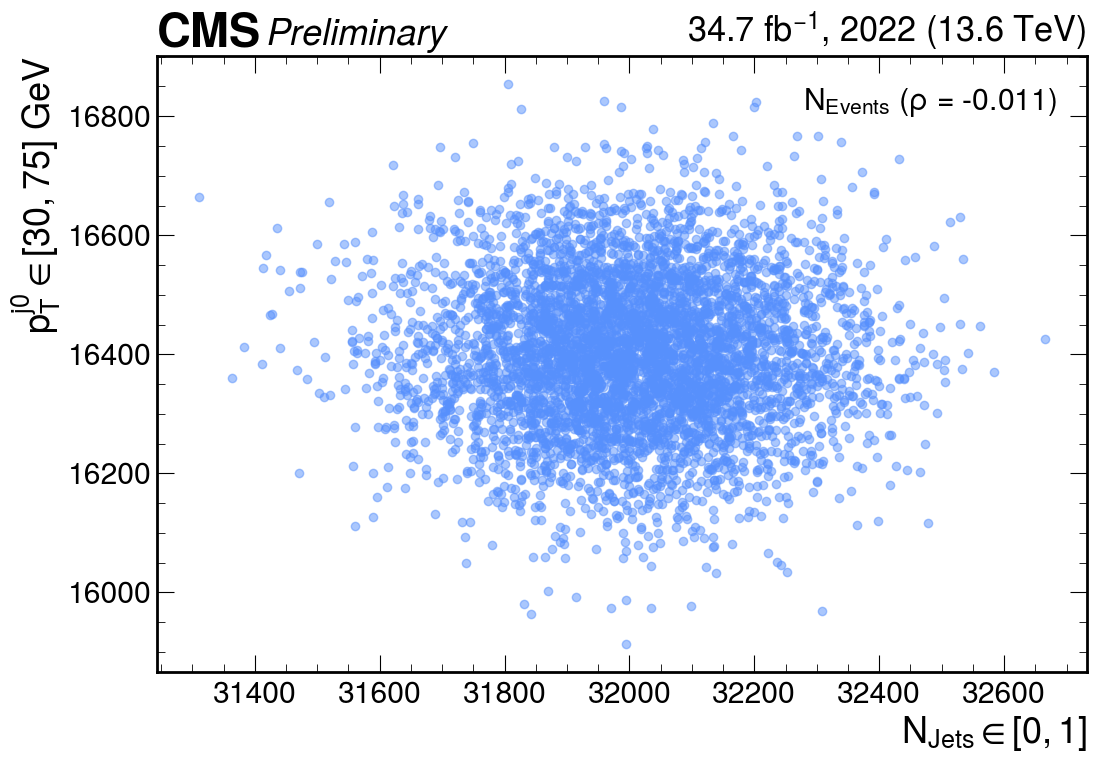

In [45]:

x = df_njcat0["bin0"]
y = df_ptj0cat0["bin1"]

# Pearson correlation coefficient
corr = np.corrcoef(x, y)[0, 1]


plt.figure(figsize=(12, 8))
hep.set_style("CMS")
hep.cms.label("Preliminary", loc=0, data=True, lumi=34.7, com=13.6, year=2022)
plt.scatter(
    x,
    y,
    alpha=0.5,
    label=fr"$N_{{Events}}$ ($\rho$ = {corr:.3f})"
)
plt.xlabel(r"$N_{Jets} \in [0,1]$")
plt.ylabel(r"$p_{T}^{j0} \in [30,75]\ GeV$")
plt.legend()
plt.savefig("bootstrap_nj_bin0_ptj0_bin1_cat0.pdf", dpi=300)

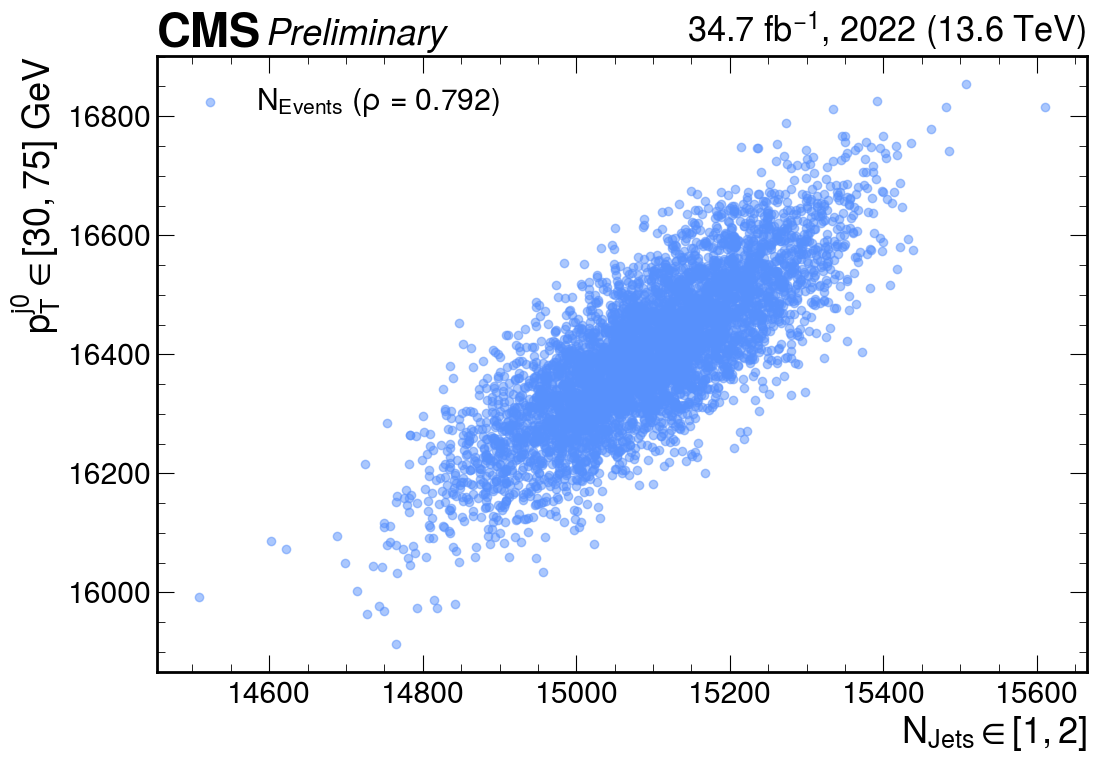

In [44]:

x = df_njcat0["bin1"]
y = df_ptj0cat0["bin1"]

# Pearson correlation coefficient
corr = np.corrcoef(x, y)[0, 1]


plt.figure(figsize=(12, 8))
hep.set_style("CMS")
hep.cms.label("Preliminary", loc=0, data=True, lumi=34.7, com=13.6, year=2022)
plt.scatter(
    x,
    y,
    alpha=0.5,
    label=fr"$N_{{Events}}$ ($\rho$ = {corr:.3f})"
)
plt.xlabel(r"$N_{Jets} \in [1,2]$")
plt.ylabel(r"$p_{T}^{j0} \in [30,75]\ GeV$")
plt.legend()
plt.savefig("bootstrap_nj_bin1_ptj0_bin1_cat0.pdf", dpi=300)

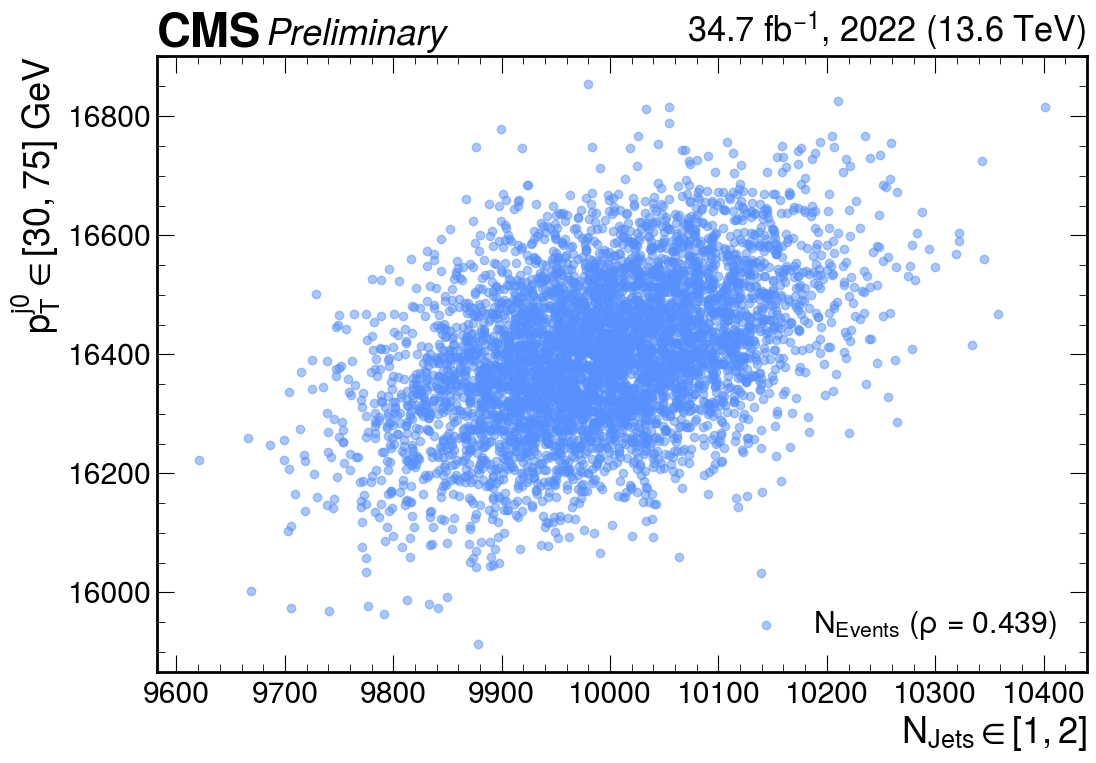

In [43]:
x = df_pthcat0["bin3"]
y = df_ptj0cat0["bin1"]

# Pearson correlation coefficient
corr = np.corrcoef(x, y)[0, 1]


plt.figure(figsize=(12, 8))
hep.set_style("CMS")
hep.cms.label("Preliminary", loc=0, data=True, lumi=34.7, com=13.6, year=2022)
plt.scatter(
    x,
    y,
    alpha=0.5,
    label=fr"$N_{{Events}}$ ($\rho$ = {corr:.3f})"
)
plt.xlabel(r"$N_{Jets} \in [1,2]$")
plt.ylabel(r"$p_{T}^{j0} \in [30,75]\ GeV$")
plt.legend()
plt.savefig("bootstrap_pth_bin3_ptj0_bin1_cat0.pdf", dpi=300)